<a href="https://colab.research.google.com/github/Prakshi16/Handwritten-Digit-Recognition/blob/main/neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


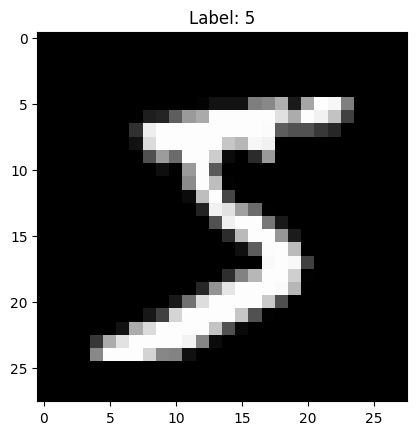

Data augmentation is skipped.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# 2. Normalize pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# (Optional) Expand dimensions to fit CNN input shape if needed later
# x_train = np.expand_dims(x_train, axis=-1)
# x_test = np.expand_dims(x_test, axis=-1)

# 3. View one sample image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# 4. (Optional) Data augmentation
# Only do this if you want to artificially expand the training dataset
augment_data = False  # set this to True to enable augmentation

if augment_data:
    datagen = ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1
    )
    # Reshape to (num_samples, 28, 28, 1) if needed for CNN later
    x_train_aug = np.expand_dims(x_train, axis=-1)
    datagen.fit(x_train_aug)
    print("Data augmentation is enabled.")
else:
    print("Data augmentation is skipped.")

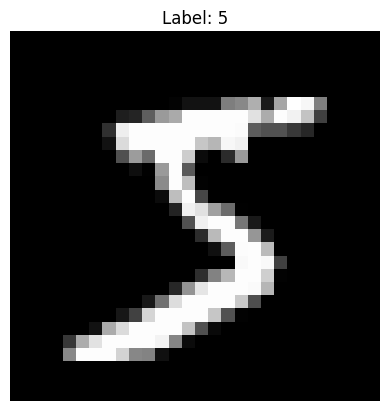

In [ ]:
#loading MNIST
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = mnist.load_data()
#Normalize pixel values
x_train = x_train/255.0
x_test = x_test / 255.0
#flatten the image:
x_train = x_train.reshape(-1, 784)

index = 0
image = x_train[index].reshape(28, 28)
plt.imshow(image, cmap = 'gray')
plt.title(f"Label: {y_train[index]}")
plt.axis('off')
plt.show()

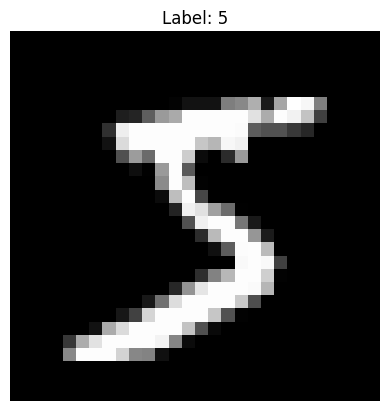

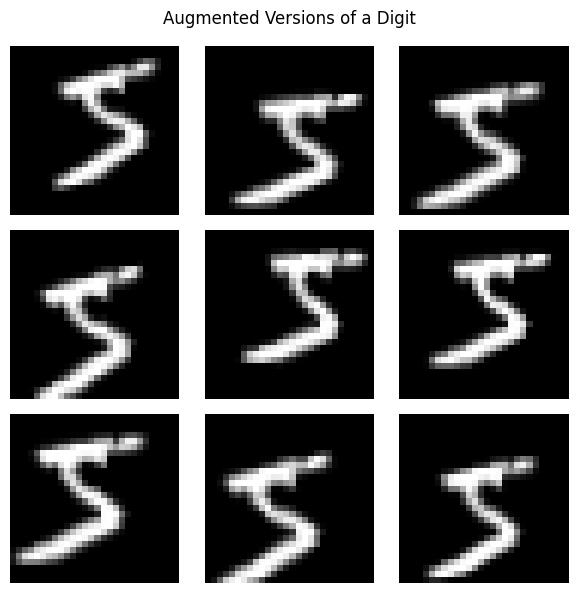

In [ ]:
#loading MNIST
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
(x_train, y_train), (x_test, y_test) = mnist.load_data()
#Normalize pixel values
x_train = x_train/255.0
x_test = x_test / 255.0
#flatten the image:
x_train = x_train.reshape(-1, 28, 28, 1)

index = 0
image = x_train[index].reshape(28, 28)
plt.imshow(image, cmap = 'gray')
plt.title(f"Label: {y_train[index]}")
plt.axis('off')
plt.show()

print(\n)

datagen = ImageDataGenerator(
    rotation_range = 10,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

datagen.fit(x_train.reshape(-1,28,28,1))

sample = x_train[0]
sample = np.expand_dims(sample, 0)
aug_iter = datagen.flow(sample, batch_size = 1)
plt.figure(figsize = (6,6))
for i in range(9):
  plt.subplot(3, 3, i+1)
  augmented_image = next(aug_iter)[0].reshape(28,28)
  plt.imshow(augmented_image, cmap = 'gray')
  plt.axis('off')
plt.suptitle("Augmented Versions of a Digit")
plt.tight_layout()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


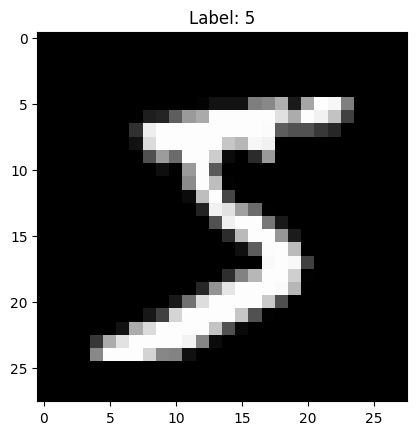

Data augmentation is skipped.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8570 - loss: 0.4862
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9553 - loss: 0.1506
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9657 - loss: 0.1117
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9709 - loss: 0.0929
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9775 - loss: 0.0744
313/313 - 1s - 3ms/step - accuracy: 0.9779 - loss: 0.0798

Test accuracy: 0.9779000282287598


In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

#normalize pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

#view one sample image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

#data augmentation (optional)
augment_data = False

if augment_data:
    datagen = ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1
    )
    x_train_aug = np.expand_dims(x_train, axis=-1)
    datagen.fit(x_train_aug)
    print("Data augmentation is enabled.")
else:
    print("Data augmentation is skipped.")

#Build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  # Converts 28x28 into 784
    tf.keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons
    tf.keras.layers.Dropout(0.2),                   # Prevents overfitting
    tf.keras.layers.Dense(10, activation='softmax') # Output layer: 10 classes (0-9)
])

#Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Train the model
model.fit(x_train, y_train, epochs=5)  # You can increase epochs if needed

#Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("\nTest accuracy:", test_acc)
